# Task 11 — Decision Tree and Comparison with Logistic Regression

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

In [4]:
# from previous notebook cells
df = pd.read_csv("../data/loan_data.csv")
df.dropna(inplace=True)
df = df.drop_duplicates().reset_index(drop=True)
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])

feature_cols = ['age','income','loan_amount','credit_score','employment_years','education']
X = df[feature_cols]
y = df['approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

### Train Decision Tree

In [6]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train_s, y_train)
dt_pred = dt.predict(X_test_s)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred, target_names=['Rejected','Approved']))

Decision Tree
Accuracy: 0.8888888888888888
              precision    recall  f1-score   support

    Rejected       0.50      0.33      0.40         6
    Approved       0.92      0.96      0.94        48

    accuracy                           0.89        54
   macro avg       0.71      0.65      0.67        54
weighted avg       0.87      0.89      0.88        54



Train Logistic rtegression

In [10]:
lr = LogisticRegression()
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred, target_names=['Rejected','Approved']))

Logistic Regression
Accuracy: 0.9074074074074074
              precision    recall  f1-score   support

    Rejected       0.67      0.33      0.44         6
    Approved       0.92      0.98      0.95        48

    accuracy                           0.91        54
   macro avg       0.79      0.66      0.70        54
weighted avg       0.89      0.91      0.89        54



### Compare both models

In [8]:
lr = LogisticRegression()
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)

print(f"{'Model':<25} {'Accuracy':>10} {'F1':>10}")
print("-" * 48)
for name, preds in [("Logistic Regression", lr_pred), ("Decision Tree", dt_pred)]:
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds)
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f}")

Model                       Accuracy         F1
------------------------------------------------
Logistic Regression           0.9074     0.9495
Decision Tree                 0.8889     0.9388


### Visualize Decision Tree

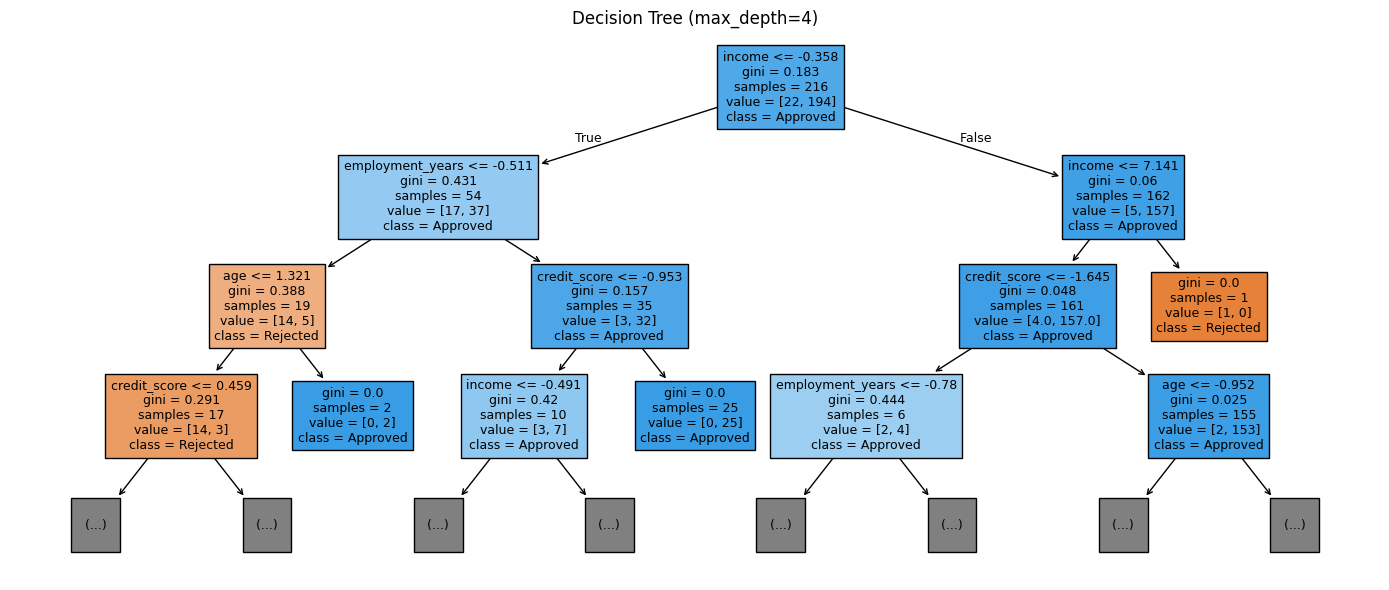

In [9]:
plt.figure(figsize=(14, 6))
plot_tree(dt, feature_names=feature_cols, class_names=['Rejected','Approved'],
          filled=True, max_depth=3, fontsize=9)
plt.title("Decision Tree (max_depth=4)")
plt.tight_layout()
plt.savefig("decision_tree.png")
plt.show()

 logistic regression performed slightly better ( both accuracy and f1 are high)